# Stage 10b — Classification (the project goal)

**Project:** TSM next-day direction forecast. This notebook is the *classification
track* — the actual project deliverable: predict whether TSM will close **up (1)** or
**down (0)** tomorrow, using only today's and recent market data.

It builds a `StandardScaler -> LogisticRegression` pipeline on the leakage-safe feature
set from `src/features.py`, evaluates it time-aware, and reports honest, risk-aware
metrics.

In [1]:
# --- run me first (notebooks/ -> project/ root) ---
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.modeling import (load_modeling_data, prepare_features, time_aware_split,
                          run_logistic_classification, MODEL_FEATURES)
%matplotlib inline
print('ok')

ok


## 1. Load data & the binary target

The label ``target`` is already engineered in `src/cleaning.py` as
`close.shift(-1) > close`. The features come from `src/features.py`: lag/rolling returns
(`return_1d/5d/20d`), trend position (`close_to_ma_*`, `ma_5_20_spread`), volume surge,
intraday range and overnight gap — every one computed from information available by
today's close, so predicting *tomorrow* leaks nothing.

In [2]:
df = load_modeling_data()
X, y_reg, y_clf = prepare_features(df)
print('design matrix X:', X.shape)
print('features:', MODEL_FEATURES)
print('label balance:')
print(y_clf.value_counts().rename({1: 'up (1)', 0: 'down (0)'}).to_string())
print('up share: %.3f' % y_clf.mean())

design matrix X: (1486, 9)
features: ['return_1d', 'return_5d', 'return_20d', 'close_to_ma_5', 'close_to_ma_20', 'ma_5_20_spread', 'volume_ratio_20', 'intraday_range', 'overnight_gap']
label balance:
target
up (1)      759
down (0)    727
up share: 0.511


## 2. Time-aware split

Same chronological rule as the regression track — first 80% train, last 20% test, no
shuffle. (A random split would put tomorrow's label next to today's features in the
training set and overstate skill.)

In [3]:
X_train, X_test, y_train, y_test = time_aware_split(X, y_clf)
print(f'train: {len(X_train)} rows  (up share {y_train.mean():.3f})')
print(f'test : {len(X_test)} rows  (up share {y_test.mean():.3f})')

train: 1188 rows  (up share 0.508)
test : 298 rows  (up share 0.523)


## 3. Fit the logistic pipeline

`StandardScaler -> LogisticRegression`. We report accuracy against the **majority-class
baseline** (always predicting "up" on the test set) — accuracy alone is misleading when
classes are slightly unbalanced.

In [4]:
res = run_logistic_classification(X_train, y_train, X_test, y_test)
print(f"accuracy : {res['accuracy']:.4f}   (baseline {res['baseline_accuracy']:.4f})")
print(f"precision: {res['precision']:.4f}")
print(f"recall   : {res['recall']:.4f}")
print(f"F1       : {res['f1']:.4f}")
print(f"AUC      : {res['auc']:.4f}")
print('confusion matrix (rows=true, cols=pred):')
print(res['confusion'])

accuracy : 0.5000   (baseline 0.5235)
precision: 0.5220
recall   : 0.5321
F1       : 0.5270
AUC      : 0.5301
confusion matrix (rows=true, cols=pred):
[[66 76]
 [73 83]]


## 4. Confusion matrix & predicted probabilities

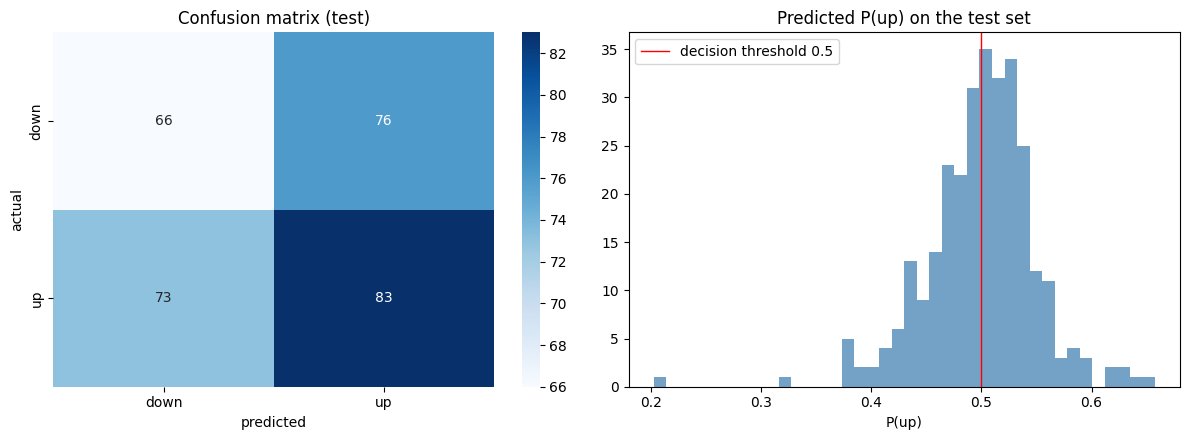

P(up) distribution: mean 0.500  std 0.050  min 0.202  max 0.658


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(res['confusion'], annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['down', 'up'], yticklabels=['down', 'up'])
axes[0].set_title('Confusion matrix (test)')
axes[0].set_xlabel('predicted'); axes[0].set_ylabel('actual')

axes[1].hist(res['y_prob'], bins=40, alpha=0.75, color='steelblue')
axes[1].axvline(0.5, color='r', lw=1, label='decision threshold 0.5')
axes[1].set_title('Predicted P(up) on the test set')
axes[1].set_xlabel('P(up)'); axes[1].legend()
plt.tight_layout(); plt.show()

print('P(up) distribution: mean %.3f  std %.3f  min %.3f  max %.3f' % (
    res['y_prob'].mean(), res['y_prob'].std(), res['y_prob'].min(), res['y_prob'].max()))

## 5. Coefficients

Standardized logistic coefficients: the log-odds change in P(up) for a 1-standard-
deviation increase in each feature. Signs are the interpretable signal here.

,feature,std_coef
6,volume_ratio_20,0.047722
4,close_to_ma_20,-0.015590
2,return_20d,0.008361
0,return_1d,-0.005438
3,close_to_ma_5,0.003757
5,ma_5_20_spread,0.002930
1,return_5d,-0.002284
8,overnight_gap,0.001576
7,intraday_range,-0.001327


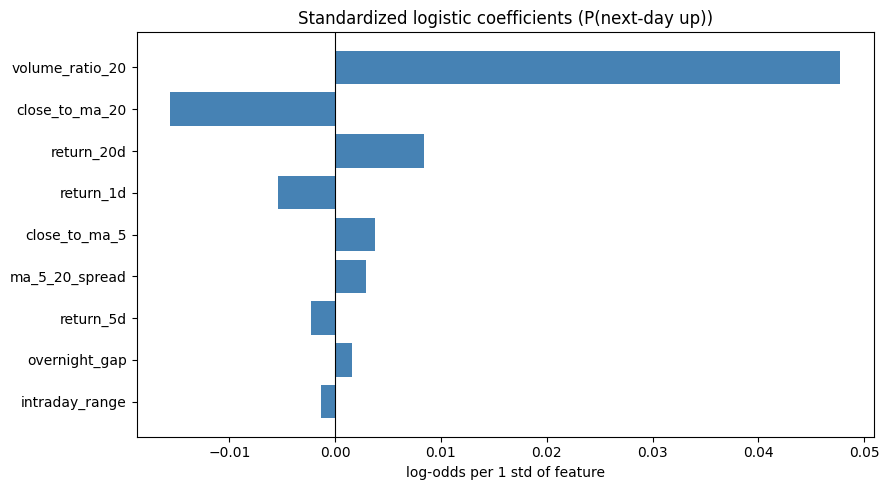

In [6]:
coefs = res['coefs']
display(coefs)
plt.figure(figsize=(9, 5))
plt.barh(coefs['feature'][::-1], coefs['std_coef'][::-1], color='steelblue')
plt.axvline(0, color='black', lw=0.8)
plt.title('Standardized logistic coefficients (P(next-day up))')
plt.xlabel('log-odds per 1 std of feature')
plt.tight_layout(); plt.show()

## 6. Auto-try variations

"Automate the modeling so you can auto-try some variations": compare the logistic
baseline against a couple of nonlinear learners and a majority-class dummy on the same
time-aware split.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

def _eval(model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    p = model.predict(Xte)
    try:
        auc = roc_auc_score(yte, model.predict_proba(Xte)[:, 1])
    except Exception:
        auc = float('nan')
    return round(float(accuracy_score(yte, p)), 4), round(float(auc), 4)

rows = []
models = {
    'LogisticRegression (baseline)': Pipeline([('s', StandardScaler()),
                                               ('m', LogisticRegression(max_iter=1000))]),
    'RandomForest (nonlinear)': RandomForestClassifier(n_estimators=300, random_state=42),
    'HistGradientBoosting (nonlinear)': HistGradientBoostingClassifier(random_state=42),
    'Dummy (majority class)': DummyClassifier(strategy='most_frequent'),
}
for name, m in models.items():
    acc, auc = _eval(m, X_train, X_test, y_train, y_test)
    rows.append({'model': name, 'accuracy': acc, 'AUC': auc})

pd.DataFrame(rows)

,model,accuracy,AUC
0,LogisticRegression (baseline),0.5000,0.5301
1,RandomForest (nonlinear),0.5336,0.5439
2,HistGradientBoosting (nonlinear),0.5000,0.5097
3,Dummy (majority class),0.5235,0.5000


## 7. Interpretation (risk-aware)

**The headline result is honest: there is no reliable next-day edge in this data.**
Accuracy sits at ~50% — right at the majority-class baseline — and AUC is close to 0.5,
which is the chance value. The nonlinear learners do no better. That is expected for a
liquid large-cap name: next-day direction is dominated by noise, and any real signal is
small relative to daily volatility.

**What the coefficients say (weakly, since the model is near chance):**
`volume_ratio_20` has the largest positive coefficient — unusually heavy volume slightly
tilts the odds toward an up day — while `close_to_ma_20` is mildly negative (price
extended above its 20-day mean slightly precedes a down day). These are directionally
plausible (surge = momentum, overextension = mean-reversion) but too small to trade on.

**Assumptions & risks:**
* **Leakage-safe by construction** — all features are known at today's close; the split
  is chronological. The near-chance result is *not* caused by leakage.
* **Stationary features** — price-scaled `ma_5/ma_20/vol_20` were excluded so the model
  doesn't learn the price level.
* **Weak stationarity** — a model trained across 2020–2024 may not transfer to a 2024–2025
  regime if the drift or volatility changed.
* **Class imbalance is mild** (~51% up), so accuracy is a fair summary here, but
  precision/recall/AUC are reported too.
* **No calibration of the decision threshold** — 0.5 is the default; with asymmetric
  up/down costs a stakeholder might prefer a different threshold.

**Bottom line for the stakeholder:** treat the model as a *structured description of the
data*, not a money-making signal. The honest finding — no exploitable edge — is itself the
key deliverable: it protects a decision-maker from over-trusting a black-box that would
also score ~50%.